# F1 model improvement study

This notebook keeps the baseline notebook unchanged.

It does these tasks:

1. Check the local data.
2. Re-run the current baseline.
3. Test new race-state features.
4. Test a model for future position change.
5. Test the effect of starting-grid features.
6. Report metrics by race and by lap checkpoint.
7. Run optional Bayesian tuning.
8. Test the final model protocol on 2026 data.

In [73]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from xgboost import XGBRegressor

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import IN_RACE_PATH, PRE_RACE_PATH
from src.metrics import regression_metrics
from src.modeling import (
    IN_RACE_FEATURES,
    IN_RACE_FEATURES_ABLATION,
    IN_RACE_RESIDUAL_FEATURES,
    IN_RACE_STATE_FEATURES,
    PRE_RACE_FEATURES,
    add_position_delta_target,
    encode_categoricals,
    fill_numeric,
    oof_pre_race_predictions,
    reconstruct_finish_from_delta,
)

FIGURES_DIR = ROOT / 'figures' / 'improvement'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR = ROOT / 'artifacts' / 'improvement'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

BASELINE_PRE_RACE_FEATURES = [
    'grid_position',
    'driver_roll_finish_5',
    'team_roll_finish_5',
    'track_avg_finish',
    'driver_quali_race_conv',
    'weather_air_temp',
    'weather_track_temp',
    'weather_humidity',
    'weather_rainfall',
    'driver_enc',
    'team_enc',
    'circuit_enc',
]

## 1. Check the data

In [74]:
pre = pd.read_parquet(PRE_RACE_PATH)
laps = pd.read_parquet(IN_RACE_PATH)

pre_races = set(pre['race_id'].astype(str))
lap_races = set(laps['race_id'].astype(str))
assert pre_races == lap_races, 'The two files do not contain the same races.'

coverage = (
    pre.groupby('year')['race_id'].nunique().rename('races')
)
coverage = coverage.to_frame()
coverage['pre_rows'] = pre.groupby('year').size()
coverage['lap_rows'] = laps.groupby('year').size()
display(coverage)
print(f'Pre-race rows: {len(pre):,}')
print(f'In-race rows: {len(laps):,}')
print(f'Races: {len(pre_races)}')
print(f'Years: {sorted(pre.year.unique())}')

# This old field is not used by the new models.
laps = laps.drop(columns=['laps_since_pit'], errors='ignore')

,races,pre_rows,lap_rows
year,,,
2019,21,420,23648
2020,17,340,18308
2021,22,439,23731
2022,22,439,23536
2023,22,439,24382
2024,24,479,26578
2025,24,479,26659
2026,11,242,12707


Pre-race rows: 3,277
In-race rows: 179,549
Races: 163
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## 2. Define the evaluation protocol

In [75]:
def make_xgb(params=None):
    settings = {
        'n_estimators': 400,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'objective': 'reg:squarederror',
        'n_jobs': -1,
        'random_state': 42,
    }
    if params:
        settings.update(params)
    return XGBRegressor(**settings)

def race_weighted_metrics(frame, predictions):
    work = frame[['race_id', 'finish_position']].copy()
    work['prediction'] = np.asarray(predictions, dtype=float)
    rows = []
    for race_id, group in work.groupby('race_id'):
        values = regression_metrics(group['finish_position'], group['prediction'])
        rows.append(values)
    return pd.DataFrame(rows).mean(numeric_only=True).to_dict()

def prepare_protocol(train_years, validation_year, test_year):
    pre_train = pre[pre.year.isin(train_years)].copy()
    pre_val = pre[pre.year == validation_year].copy()
    pre_test = pre[pre.year == test_year].copy()

    _, (pre_train, pre_val, pre_test) = encode_categoricals(
        pre_train, pre_val, pre_test
    )
    pre_numeric = [
        c for c in BASELINE_PRE_RACE_FEATURES
        if c not in {'driver_enc', 'team_enc', 'circuit_enc'}
    ]
    pre_train, pre_val, pre_test = fill_numeric(
        pre_train, pre_val, pre_test,
        cols=pre_numeric + ['driver_enc', 'team_enc', 'circuit_enc'],
    )
    oof, pre_model = oof_pre_race_predictions(pre_train, BASELINE_PRE_RACE_FEATURES)
    pre_train['pre_race_pred'] = oof
    pre_val['pre_race_pred'] = pre_model.predict(pre_val[BASELINE_PRE_RACE_FEATURES])
    pre_test['pre_race_pred'] = pre_model.predict(pre_test[BASELINE_PRE_RACE_FEATURES])

    pred_map = pd.concat([
        pre_train[['race_id', 'driver', 'pre_race_pred']],
        pre_val[['race_id', 'driver', 'pre_race_pred']],
        pre_test[['race_id', 'driver', 'pre_race_pred']],
    ], ignore_index=True)
    lap_data = laps.merge(pred_map, on=['race_id', 'driver'], how='inner')
    lap_train = lap_data[lap_data.year.isin(train_years)].copy()
    lap_val = lap_data[lap_data.year == validation_year].copy()
    lap_test = lap_data[lap_data.year == test_year].copy()

    _, (lap_train, lap_val, lap_test) = encode_categoricals(
        lap_train, lap_val, lap_test,
        cols=['driver', 'team', 'circuit', 'compound'],
    )
    fill_cols = sorted(set(IN_RACE_FEATURES + IN_RACE_STATE_FEATURES + ['compound_enc']))
    lap_train, lap_val, lap_test = fill_numeric(
        lap_train, lap_val, lap_test, cols=fill_cols
    )
    return {
        'pre_train': pre_train, 'pre_val': pre_val, 'pre_test': pre_test,
        'lap_train': lap_train.reset_index(drop=True),
        'lap_val': lap_val.reset_index(drop=True),
        'lap_test': lap_test.reset_index(drop=True),
    }

## 3. Re-run the baseline and test state models

The first protocol uses 2019–2023 for training, 2024 for validation, and 2025 for test.

In [76]:
protocol = prepare_protocol(list(range(2019, 2024)), 2024, 2025)
lap_train = protocol['lap_train']
lap_val = protocol['lap_val']
lap_test = protocol['lap_test']

model_specs = {
    'XGB baseline': ('finish', IN_RACE_FEATURES),
    'XGB ablation': ('finish', IN_RACE_FEATURES_ABLATION),
    'State direct': ('finish', IN_RACE_STATE_FEATURES),
    'State direct no prior': (
        'finish', [c for c in IN_RACE_STATE_FEATURES if c != 'pre_race_pred']
    ),
    'Residual with current, no grid': (
        'delta', [
            c for c in IN_RACE_STATE_FEATURES
            if c not in {'pre_race_pred', 'position_delta_from_grid'}
        ]
    ),
    'Residual without current, no grid': (
        'delta', [
            c for c in IN_RACE_STATE_FEATURES
            if c not in {'current_position', 'pre_race_pred', 'position_delta_from_grid'}
        ]
    ),
}

predictions = {}
models = {}
result_rows = []
for name, (target_type, features) in model_specs.items():
    train_frame = lap_train.copy()
    if target_type == 'delta':
        train_frame = add_position_delta_target(train_frame)
        target = 'finish_delta'
    else:
        target = 'finish_position'

    model = make_xgb()
    model.fit(train_frame[features], train_frame[target])
    models[name] = {'model': model, 'features': features, 'target_type': target_type}

    split_predictions = {}
    for split_name, frame in [('val', lap_val), ('test', lap_test)]:
        pred = model.predict(frame[features])
        if target_type == 'delta':
            pred = reconstruct_finish_from_delta(frame['current_position'], pred)
        split_predictions[split_name] = pred
        result_rows.append({
            'model': name, 'split': split_name, 'weighting': 'row',
            **regression_metrics(frame['finish_position'], pred),
        })
        result_rows.append({
            'model': name, 'split': split_name, 'weighting': 'race',
            **race_weighted_metrics(frame, pred),
        })
    predictions[name] = split_predictions

results = pd.DataFrame(result_rows).sort_values(['split', 'weighting', 'mae', 'model'])
display(results.round(4))

,model,split,weighting,mae,rmse,top1_exact,top3_hit,top10_hit
7,XGB ablation,test,race,2.2079,3.0658,0.1866,0.8234,0.9793
3,XGB baseline,test,race,2.2666,3.1334,0.1797,0.8164,0.9794
23,"Residual without current, no grid",test,race,2.3210,3.1801,0.1691,0.8075,0.9788
19,"Residual with current, no grid",test,race,2.4555,3.3124,0.1596,0.7724,0.9818
15,State direct no prior,test,race,2.5130,3.3462,0.1504,0.7610,0.9814
11,State direct,test,race,2.5424,3.3632,0.1400,0.7604,0.9813
6,XGB ablation,test,row,2.2233,3.2673,0.1871,0.8200,0.9786
2,XGB baseline,test,row,2.2804,3.3430,0.1805,0.8135,0.9785
22,"Residual without current, no grid",test,row,2.3381,3.3964,0.1689,0.8039,0.9781
18,"Residual with current, no grid",test,row,2.4625,3.4906,0.1594,0.7708,0.9812


## 4. Optional Bayesian tuning

This cell uses 2019–2022 for training and 2023 for validation. It does not use 2024, 2025, or 2026 during the search.

The default target is the finish-position change from the current lap. Set `TUNING_TARGET` to `baseline` to tune the original target instead.

In [77]:
try:
    import optuna
except ImportError:
    optuna = None
    print('Optuna is not installed. Run: uv add optuna')

TUNING_TRIALS = 30
TUNING_TARGET = 'residual'
TUNING_FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]

def tuning_checkpoint_rows(frame):
    parts = []
    for fraction in TUNING_FRACTIONS:
        work = frame.copy()
        scheduled = work.groupby('race_id')['scheduled_laps'].first()
        work['_target_lap'] = work['race_id'].map(scheduled) * fraction
        work = work[work['lap_number'] <= work['_target_lap']]
        row_ids = work.groupby(['race_id', 'driver'])['lap_number'].idxmax()
        selected = work.loc[row_ids].copy()
        selected['checkpoint'] = fraction
        parts.append(selected)
    return pd.concat(parts, ignore_index=True)

def tuning_score(frame, predictions):
    score_frame = frame[['race_id', 'checkpoint']].copy()
    score_frame['absolute_error'] = np.abs(
        frame['finish_position'].to_numpy() - np.asarray(predictions)
    )
    by_race = score_frame.groupby('race_id')['absolute_error'].mean()
    return float(by_race.mean())

if optuna is not None:
    inner_protocol = prepare_protocol([2019, 2020, 2021, 2022], 2023, 2024)
    inner_train = inner_protocol['lap_train']
    inner_valid = tuning_checkpoint_rows(inner_protocol['lap_val'])

    if TUNING_TARGET == 'baseline':
        tuning_features = IN_RACE_FEATURES
        tuning_target = 'finish_position'
    else:
        tuning_features = [
            c for c in IN_RACE_STATE_FEATURES
            if c not in {'pre_race_pred', 'position_delta_from_grid'}
        ]
        inner_train = add_position_delta_target(inner_train)
        inner_valid = add_position_delta_target(inner_valid)
        tuning_target = 'finish_delta'

    def trial_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 900),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.60, 1.00),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 30.0, log=True),
            'objective': 'reg:squarederror',
            'eval_metric': 'mae',
            'early_stopping_rounds': 50,
            'n_jobs': -1,
            'random_state': 42,
        }
        model = XGBRegressor(**params)
        model.fit(
            inner_train[tuning_features],
            inner_train[tuning_target],
            eval_set=[(inner_valid[tuning_features], inner_valid[tuning_target])],
            verbose=False,
        )
        prediction = model.predict(inner_valid[tuning_features])
        if TUNING_TARGET == 'residual':
            prediction = reconstruct_finish_from_delta(
                inner_valid['current_position'], prediction, max_position=22
            )
        return tuning_score(inner_valid, prediction)

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    study.optimize(trial_objective, n_trials=TUNING_TRIALS, show_progress_bar=True)
    TUNED_PARAMS = study.best_params.copy()
    pd.DataFrame([
        {**trial.params, 'value': trial.value, 'state': trial.state.name}
        for trial in study.trials
    ]).to_csv(ARTIFACTS_DIR / 'xgb_tuning_trials.csv', index=False)
    with open(ARTIFACTS_DIR / 'xgb_tuning_best_params.json', 'w') as handle:
        json.dump(TUNED_PARAMS, handle, indent=2)

    tuned_name = 'Tuned residual' if TUNING_TARGET == 'residual' else 'Tuned XGB baseline'
    tuned_features = tuning_features
    tuned_train = add_position_delta_target(lap_train) if TUNING_TARGET == 'residual' else lap_train
    tuned_target = 'finish_delta' if TUNING_TARGET == 'residual' else 'finish_position'
    tuned_model = XGBRegressor(
        **TUNED_PARAMS, objective='reg:squarederror', eval_metric='mae',
        n_jobs=-1, random_state=42,
    )
    tuned_model.fit(tuned_train[tuned_features], tuned_train[tuned_target])
    models[tuned_name] = {
        'model': tuned_model, 'features': tuned_features, 'target_type': TUNING_TARGET,
    }
    predictions[tuned_name] = {}
    for split_name, frame in [('val', lap_val), ('test', lap_test)]:
        prediction = tuned_model.predict(frame[tuned_features])
        if TUNING_TARGET == 'residual':
            prediction = reconstruct_finish_from_delta(
                frame['current_position'], prediction, max_position=22
            )
        predictions[tuned_name][split_name] = prediction
        result_rows.extend([
            {
                'model': tuned_name, 'split': split_name, 'weighting': 'row',
                **regression_metrics(frame['finish_position'], prediction),
            },
            {
                'model': tuned_name, 'split': split_name, 'weighting': 'race',
                **race_weighted_metrics(frame, prediction),
            },
        ])
    results = pd.DataFrame(result_rows).sort_values(
        ['split', 'weighting', 'mae', 'model']
    )
    display(pd.DataFrame([study.best_params]).round(4))
    display(results[results['model'] == tuned_name].round(4))
else:
    saved_params = ARTIFACTS_DIR / 'xgb_tuning_best_params.json'
    if saved_params.exists():
        with open(saved_params) as handle:
            TUNED_PARAMS = json.load(handle)
        print('Optuna is not installed. Loaded saved tuning parameters.')
    else:
        TUNED_PARAMS = None
        print('Optuna is not installed. Run: uv add optuna')
    tuned_name = None
    print('Bayesian tuning skipped.')

[I 2026-08-13 15:12:14,905] A new study created in memory with name: no-name-4555536b-728a-48ac-91ea-7f63445b8c65


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-13 15:12:15,200] Trial 0 finished with value: 2.1253411391607098 and parameters: {'n_estimators': 462, 'max_depth': 8, 'learning_rate': 0.061652988679205906, 'min_child_weight': 6.009974718380312, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'gamma': 3.200866785899844e-08, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 3.083434817935579}. Best is trial 0 with value: 2.1253411391607098.
[I 2026-08-13 15:12:15,317] Trial 1 finished with value: 2.176450195959721 and parameters: {'n_estimators': 696, 'max_depth': 2, 'learning_rate': 0.11135469245723131, 'min_child_weight': 12.10689693600216, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 3.939402261362697e-07, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 1.9947354703074502}. Best is trial 0 with value: 2.1253411391607098.
[I 2026-08-13 15:12:15,496] Trial 2 finished with value: 2.154648544180336 and parameters: {'n_estimators': 502, 'max_depth': 4, 'learning_rate

,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,375,8,0.0432,3.0437,0.7101,0.8996,0.0,0.0,18.9657


,model,split,weighting,mae,rmse,top1_exact,top3_hit,top10_hit
27,Tuned residual,test,race,2.4261,3.3200,0.1692,0.7745,0.9809
26,Tuned residual,test,row,2.4351,3.4851,0.1686,0.7719,0.9803
25,Tuned residual,val,race,1.9099,2.7430,0.2335,0.8527,0.9883
24,Tuned residual,val,row,1.8840,2.8545,0.2361,0.8562,0.9892


## 4.1 Tune the normal XGB target

This cell tunes the original XGB target: absolute finish position. It uses the same chronological split as the residual search. It saves separate results.

In [78]:
BASELINE_TUNED_PARAMS = None
baseline_params_path = ARTIFACTS_DIR / 'xgb_baseline_tuning_best_params.json'

if optuna is not None:
    baseline_inner_protocol = prepare_protocol([2019, 2020, 2021, 2022], 2023, 2024)
    baseline_inner_train = baseline_inner_protocol['lap_train']
    baseline_inner_valid = tuning_checkpoint_rows(baseline_inner_protocol['lap_val'])

    def baseline_trial_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 900),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.12, log=True),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.60, 1.00),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.60, 1.00),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 30.0, log=True),
            'objective': 'reg:squarederror',
            'eval_metric': 'mae',
            'early_stopping_rounds': 50,
            'n_jobs': -1,
            'random_state': 123,
        }
        model = XGBRegressor(**params)
        model.fit(
            baseline_inner_train[IN_RACE_FEATURES],
            baseline_inner_train['finish_position'],
            eval_set=[
                (baseline_inner_valid[IN_RACE_FEATURES], baseline_inner_valid['finish_position'])
            ],
            verbose=False,
        )
        prediction = model.predict(baseline_inner_valid[IN_RACE_FEATURES])
        return tuning_score(baseline_inner_valid, prediction)

    baseline_study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=123),
    )
    baseline_study.optimize(
        baseline_trial_objective,
        n_trials=TUNING_TRIALS,
        show_progress_bar=True,
    )
    BASELINE_TUNED_PARAMS = baseline_study.best_params.copy()
    pd.DataFrame([
        {**trial.params, 'value': trial.value, 'state': trial.state.name}
        for trial in baseline_study.trials
    ]).to_csv(ARTIFACTS_DIR / 'xgb_baseline_tuning_trials.csv', index=False)
    with open(baseline_params_path, 'w') as handle:
        json.dump(BASELINE_TUNED_PARAMS, handle, indent=2)
elif baseline_params_path.exists():
    with open(baseline_params_path) as handle:
        BASELINE_TUNED_PARAMS = json.load(handle)
    print('Optuna is not installed. Loaded saved normal XGB parameters.')
else:
    print('Normal XGB tuning skipped. Run: uv add optuna')

baseline_tuned_name = None
baseline_tuned_ablation_name = None
if BASELINE_TUNED_PARAMS:
    baseline_tuned_name = 'Tuned XGB baseline'
    baseline_tuned_model = make_xgb(BASELINE_TUNED_PARAMS)
    baseline_tuned_model.fit(
        lap_train[IN_RACE_FEATURES], lap_train['finish_position']
    )
    models[baseline_tuned_name] = {
        'model': baseline_tuned_model,
        'features': IN_RACE_FEATURES,
        'target_type': 'finish',
    }
    predictions[baseline_tuned_name] = {}
    for split_name, frame in [('val', lap_val), ('test', lap_test)]:
        prediction = baseline_tuned_model.predict(frame[IN_RACE_FEATURES])
        predictions[baseline_tuned_name][split_name] = prediction
        result_rows.extend([
            {
                'model': baseline_tuned_name, 'split': split_name, 'weighting': 'row',
                **regression_metrics(frame['finish_position'], prediction),
            },
            {
                'model': baseline_tuned_name, 'split': split_name, 'weighting': 'race',
                **race_weighted_metrics(frame, prediction),
            },
        ])
    results = pd.DataFrame(result_rows).sort_values(
        ['split', 'weighting', 'mae', 'model']
    )
    baseline_tuned_ablation_name = 'Tuned XGB ablation'
    baseline_tuned_ablation_model = make_xgb(BASELINE_TUNED_PARAMS)
    baseline_tuned_ablation_model.fit(
        lap_train[IN_RACE_FEATURES_ABLATION], lap_train['finish_position']
    )
    models[baseline_tuned_ablation_name] = {
        'model': baseline_tuned_ablation_model,
        'features': IN_RACE_FEATURES_ABLATION,
        'target_type': 'finish',
    }
    predictions[baseline_tuned_ablation_name] = {}
    for split_name, frame in [('val', lap_val), ('test', lap_test)]:
        prediction = baseline_tuned_ablation_model.predict(
            frame[IN_RACE_FEATURES_ABLATION]
        )
        predictions[baseline_tuned_ablation_name][split_name] = prediction
        result_rows.extend([
            {
                'model': baseline_tuned_ablation_name,
                'split': split_name,
                'weighting': 'row',
                **regression_metrics(frame['finish_position'], prediction),
            },
            {
                'model': baseline_tuned_ablation_name,
                'split': split_name,
                'weighting': 'race',
                **race_weighted_metrics(frame, prediction),
            },
        ])
    results = pd.DataFrame(result_rows).sort_values(
        ['split', 'weighting', 'mae', 'model']
    )
    display(pd.DataFrame([BASELINE_TUNED_PARAMS]).round(4))
    display(results[results['model'].isin([baseline_tuned_name, baseline_tuned_ablation_name])].round(4))

[I 2026-08-13 15:12:30,875] A new study created in memory with name: no-name-05971542-1c08-4d77-99f7-a35f48fd2419


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-13 15:12:31,989] Trial 0 finished with value: 2.269281206747578 and parameters: {'n_estimators': 688, 'max_depth': 4, 'learning_rate': 0.017571702198527987, 'min_child_weight': 5.215273055035314, 'subsample': 0.8877875879142252, 'colsample_bytree': 0.7692425840497844, 'gamma': 3.401248341931566, 'reg_alpha': 0.014570271595538578, 'reg_lambda': 1.5535550078371518}. Best is trial 0 with value: 2.269281206747578.
[I 2026-08-13 15:12:32,417] Trial 1 finished with value: 2.2689554835757915 and parameters: {'n_estimators': 474, 'max_depth': 4, 'learning_rate': 0.06120357231033418, 'min_child_weight': 3.7204514843139487, 'subsample': 0.6238711586438274, 'colsample_bytree': 0.7592177021321725, 'gamma': 0.026290563689110865, 'reg_alpha': 4.3896063362849525e-07, 'reg_lambda': 0.2720290434131154}. Best is trial 1 with value: 2.2689554835757915.
[I 2026-08-13 15:12:32,922] Trial 2 finished with value: 2.2733067901951967 and parameters: {'n_estimators': 572, 'max_depth': 5, 'learning_rat

,n_estimators,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,474,4,0.0612,3.7205,0.6239,0.7592,0.0263,0.0,0.272


,model,split,weighting,mae,rmse,top1_exact,top3_hit,top10_hit
35,Tuned XGB ablation,test,race,2.1913,3.0295,0.1803,0.8305,0.9796
31,Tuned XGB baseline,test,race,2.2216,3.0639,0.1733,0.8229,0.9791
34,Tuned XGB ablation,test,row,2.2066,3.2346,0.1803,0.8276,0.9790
30,Tuned XGB baseline,test,row,2.2366,3.2867,0.1735,0.8202,0.9784
29,Tuned XGB baseline,val,race,1.8550,2.6539,0.2323,0.8692,0.9875
33,Tuned XGB ablation,val,race,1.8812,2.6844,0.2333,0.8584,0.9885
28,Tuned XGB baseline,val,row,1.8354,2.7834,0.2351,0.8709,0.9885
32,Tuned XGB ablation,val,row,1.8587,2.7759,0.2365,0.8601,0.9895


## 4. Compare fixed lap checkpoints

This uses the latest row at or before each race fraction. It does not use a future lap.

In [79]:
def checkpoint_rows(frame, fraction):
    work = frame.copy()
    work['_row_id'] = work.index
    scheduled = work.groupby('race_id')['scheduled_laps'].first()
    work['_target_lap'] = work['race_id'].map(scheduled) * fraction
    work = work[work['lap_number'] <= work['_target_lap']]
    selected = work.groupby(['race_id', 'driver'])['lap_number'].idxmax()
    return work.loc[selected].copy()

checkpoint_rows_out = []
fractions = [0.02, 0.10, 0.25, 0.50, 0.75, 1.00]
for fraction in fractions:
    checkpoint = checkpoint_rows(lap_test, fraction)
    checkpoint_rows_out.append({
        'checkpoint': f'{fraction:.0%}',
        'races': checkpoint.race_id.nunique(),
        'drivers': len(checkpoint),
        'Naive current position': race_weighted_metrics(
            checkpoint, checkpoint['current_position']
        )['mae'],
    })
    for name, split_predictions in predictions.items():
        pred = split_predictions['test'][checkpoint['_row_id'].to_numpy()]
        checkpoint_rows_out[-1][name] = race_weighted_metrics(checkpoint, pred)['mae']

checkpoint_results = pd.DataFrame(checkpoint_rows_out)
display(checkpoint_results.round(4))

,checkpoint,races,drivers,Naive current position,XGB baseline,XGB ablation,State direct,State direct no prior,"Residual with current, no grid","Residual without current, no grid",Tuned residual,Tuned XGB baseline,Tuned XGB ablation
0,2%,23,445,2.8712,3.0920,3.0495,3.2345,3.2740,3.2920,3.3222,3.3659,3.0223,3.0400
1,10%,24,465,2.7881,2.9360,2.8672,3.1287,3.1376,3.1631,2.9954,3.1819,2.8783,2.8456
2,25%,24,465,2.7848,2.7878,2.7967,2.9970,3.0277,2.9721,2.8484,3.0104,2.7329,2.7761
3,50%,24,465,2.5101,2.4577,2.4283,2.7562,2.7022,2.6819,2.4987,2.6388,2.4269,2.4094
4,75%,24,465,1.9096,2.1042,2.0254,2.4206,2.3961,2.3095,2.0936,2.2260,2.0726,2.0181
5,100%,24,465,0.7951,1.5810,1.4479,1.9175,1.8467,1.7237,1.5041,1.5728,1.5685,1.4475


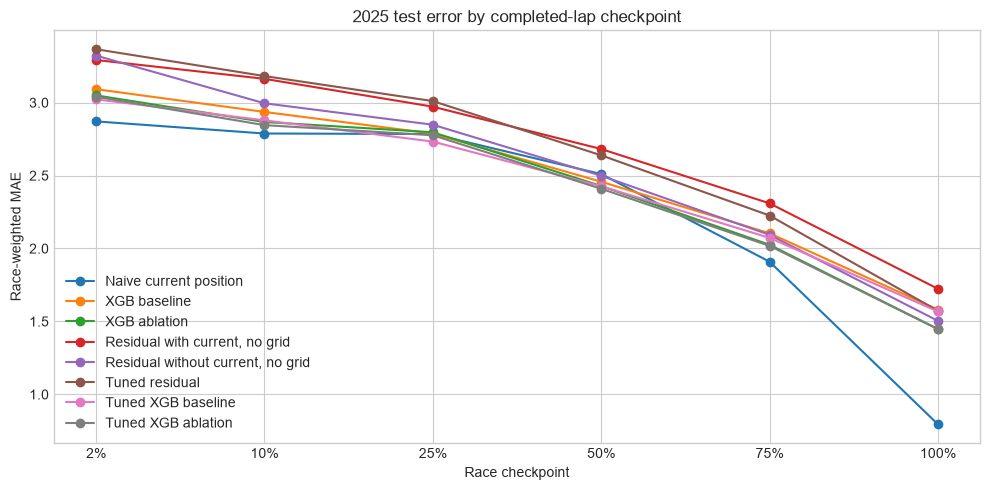

In [80]:
plot_columns = [
    'Naive current position',
    'XGB baseline',
    'XGB ablation',
    'Residual with current, no grid',
    'Residual without current, no grid',
]
if tuned_name is not None:
    plot_columns.append(tuned_name)
if baseline_tuned_name is not None:
    plot_columns.append(baseline_tuned_name)
if baseline_tuned_ablation_name is not None:
    plot_columns.append(baseline_tuned_ablation_name)
ax = checkpoint_results.set_index('checkpoint')[plot_columns].plot(
    marker='o', figsize=(10, 5)
)
ax.set_xlabel('Race checkpoint')
ax.set_ylabel('Race-weighted MAE')
ax.set_title('2025 test error by completed-lap checkpoint')
ax.figure.tight_layout()
ax.figure.savefig(FIGURES_DIR / 'mae_by_checkpoint.png', dpi=150)
plt.show()

## 5. Create comparison charts

These charts use the same test-year split as the baseline notebook.
The baseline model uses the original feature list. The improved model is the residual model with current position and without grid features.

In [81]:
comparison_models = {
    'XGB baseline': '#003566',
    'XGB ablation': '#007f5f',
    'Residual with current, no grid': '#c1121f',
}
if tuned_name is not None:
    comparison_models[tuned_name] = '#f77f00'
if baseline_tuned_name is not None:
    comparison_models[baseline_tuned_name] = '#2a9d8f'
if baseline_tuned_ablation_name is not None:
    comparison_models[baseline_tuned_ablation_name] = '#8a5a44'

test_summary = results[
    (results['split'] == 'test') & (results['weighting'] == 'row')
].copy()
test_summary[['model', 'mae', 'rmse', 'top1_exact', 'top3_hit', 'top10_hit']].round(4)
test_summary.to_csv(FIGURES_DIR / 'test_model_results.csv', index=False)
display(test_summary.round(4))

,model,split,weighting,mae,rmse,top1_exact,top3_hit,top10_hit
34,Tuned XGB ablation,test,row,2.2066,3.2346,0.1803,0.8276,0.9790
6,XGB ablation,test,row,2.2233,3.2673,0.1871,0.8200,0.9786
30,Tuned XGB baseline,test,row,2.2366,3.2867,0.1735,0.8202,0.9784
2,XGB baseline,test,row,2.2804,3.3430,0.1805,0.8135,0.9785
22,"Residual without current, no grid",test,row,2.3381,3.3964,0.1689,0.8039,0.9781
26,Tuned residual,test,row,2.4351,3.4851,0.1686,0.7719,0.9803
18,"Residual with current, no grid",test,row,2.4625,3.4906,0.1594,0.7708,0.9812
14,State direct no prior,test,row,2.5244,3.5338,0.1505,0.7591,0.9809
10,State direct,test,row,2.5544,3.5598,0.1414,0.7582,0.9807


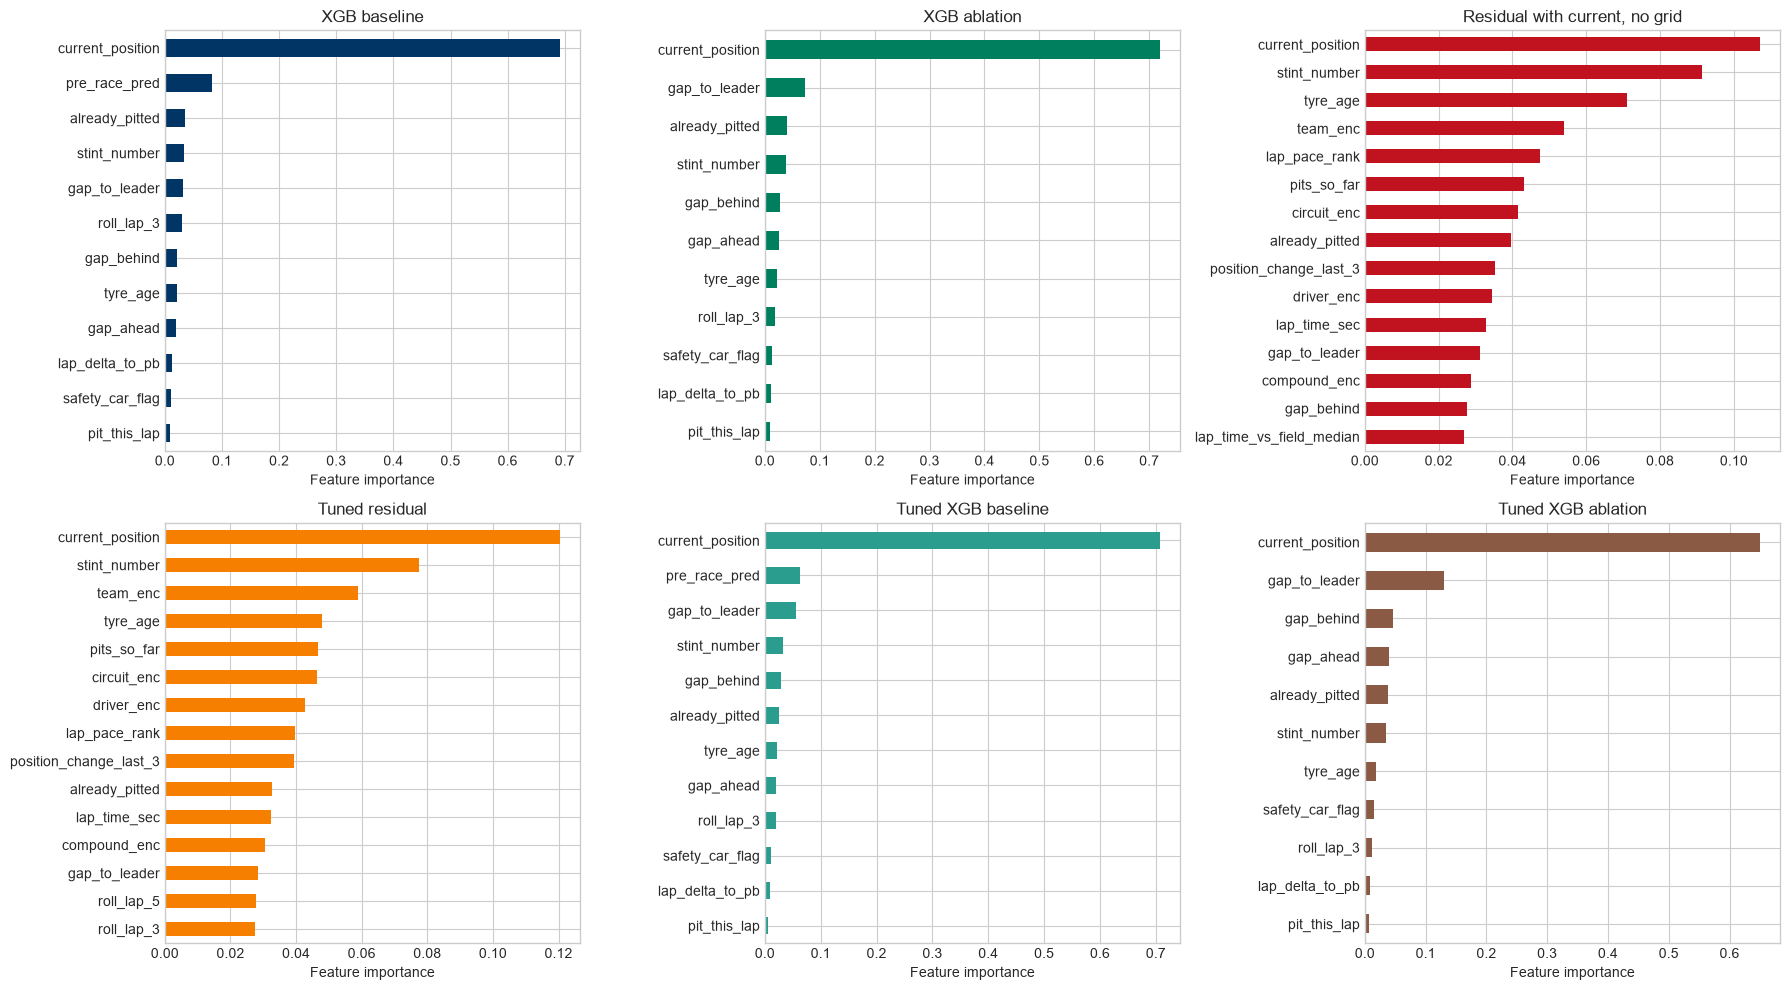

In [83]:
# Feature importance
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
model_names = list(comparison_models.keys())
if len(model_names) > 6:
    print('Showing first 6 models in the 2x3 grid.')
model_names = model_names[:6]

for ax, name in zip(axes, model_names):
    info = models[name]
    importance = pd.Series(
        info['model'].feature_importances_, index=info['features']
    ).sort_values()
    importance.tail(15).plot.barh(ax=ax, color=comparison_models[name])
    ax.set_title(name)
    ax.set_xlabel('Feature importance')

for ax in axes[len(model_names):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_feature_importance.png', dpi=150)
plt.show()

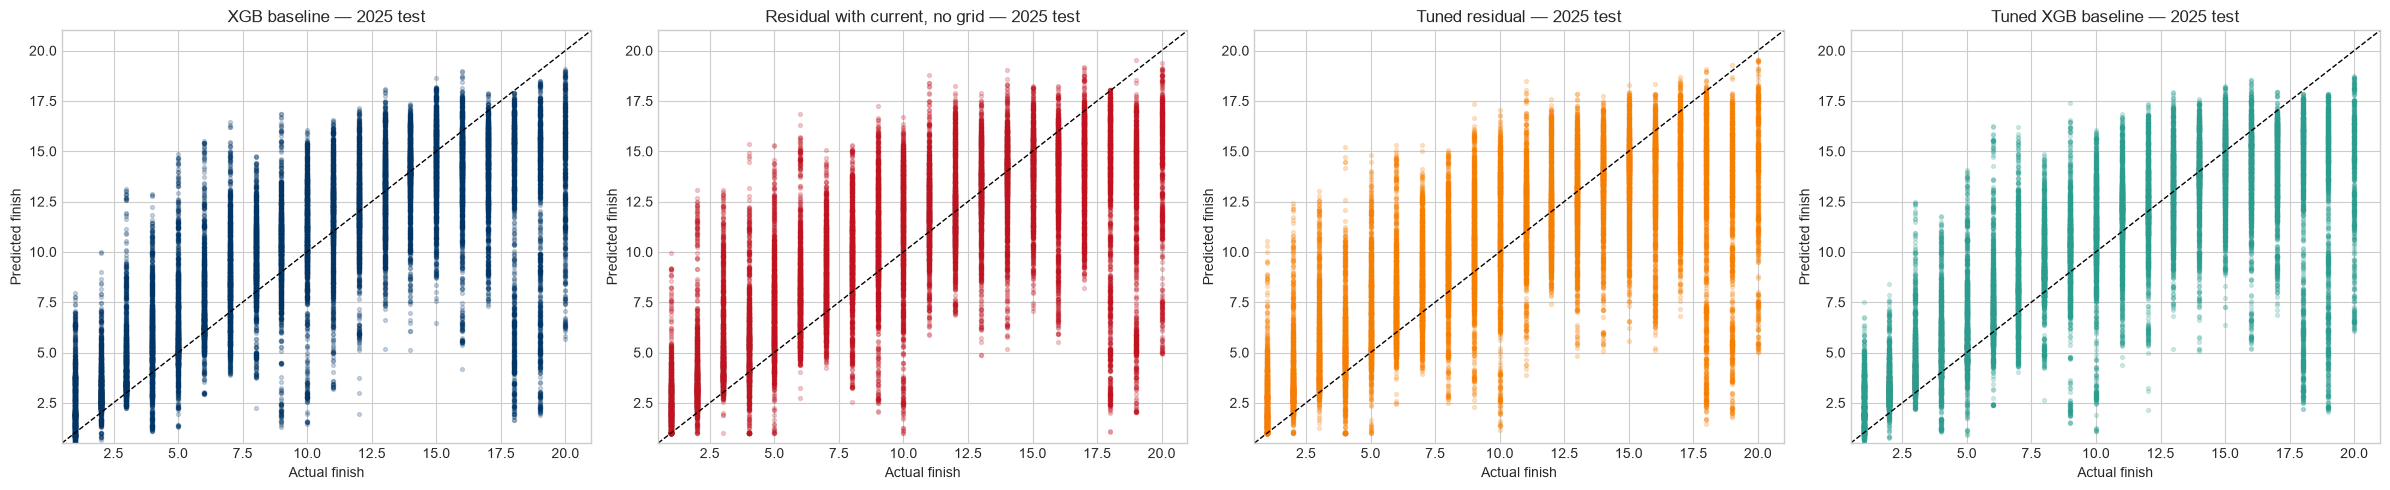

In [25]:
# Predicted versus actual finish position
fig, axes = plt.subplots(1, len(comparison_models), figsize=(6 * len(comparison_models), 5))
axes = np.atleast_1d(axes)
lims = [0.5, 21]
for ax, name in zip(axes, comparison_models):
    pred = predictions[name]['test']
    ax.scatter(
        lap_test['finish_position'], pred,
        alpha=0.20, s=8, color=comparison_models[name]
    )
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual finish')
    ax.set_ylabel('Predicted finish')
    ax.set_title(f'{name} — 2025 test')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '02_predicted_vs_actual.png', dpi=150)
plt.show()

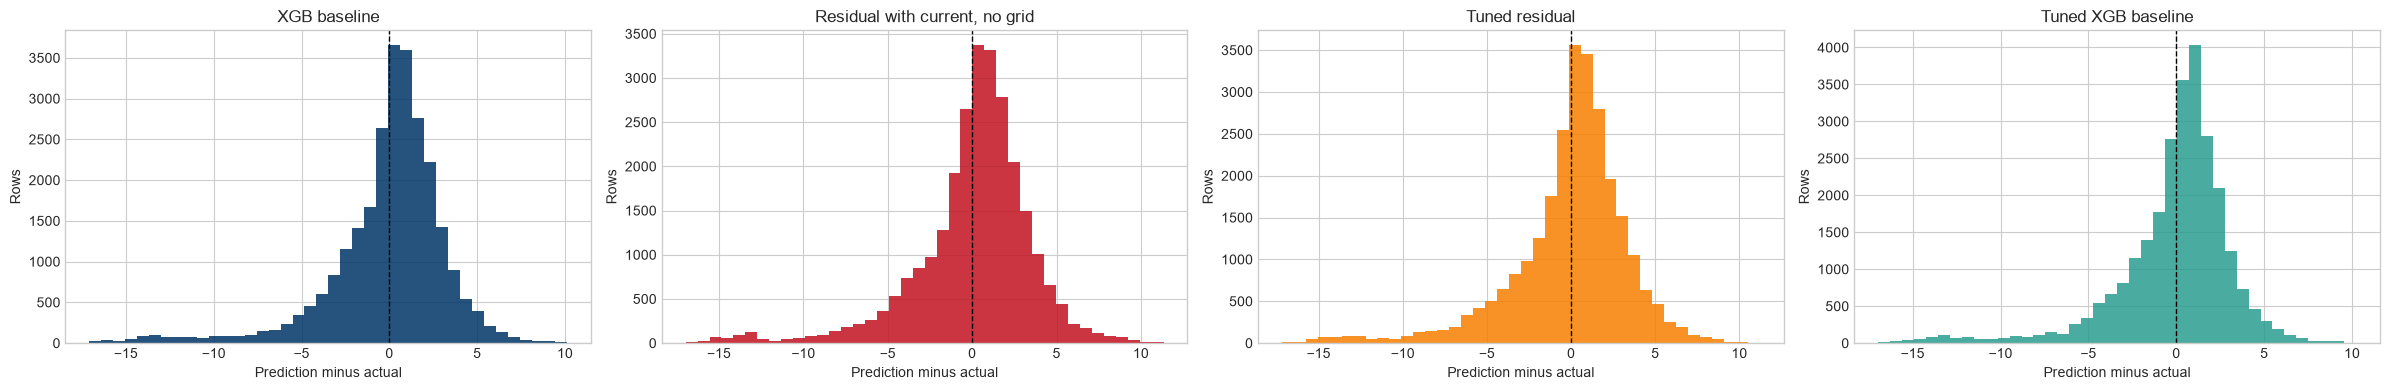

In [26]:
# Residual distributions
fig, axes = plt.subplots(1, len(comparison_models), figsize=(6 * len(comparison_models), 4))
axes = np.atleast_1d(axes)
for ax, name in zip(axes, comparison_models):
    residual = predictions[name]['test'] - lap_test['finish_position'].to_numpy()
    ax.hist(residual, bins=40, color=comparison_models[name], alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Prediction minus actual')
    ax.set_ylabel('Rows')
    ax.set_title(name)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '03_residuals.png', dpi=150)
plt.show()

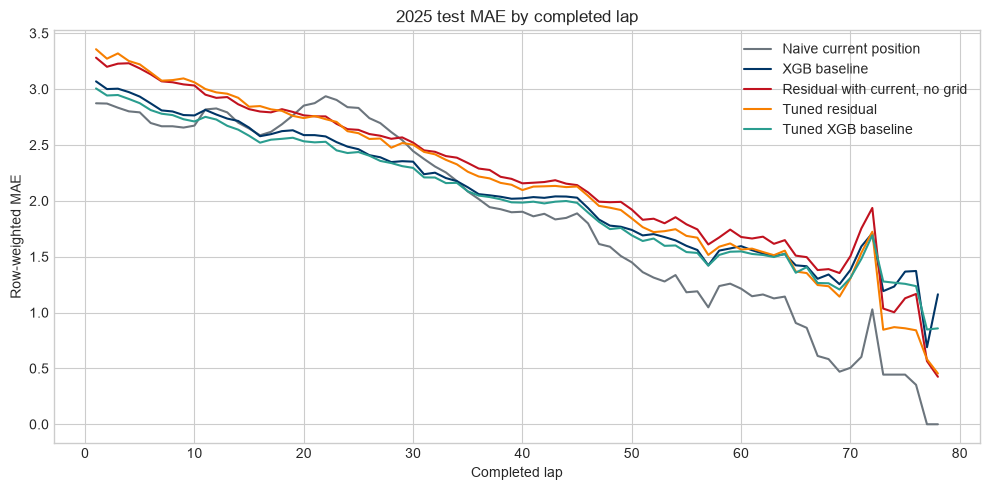

In [27]:
# MAE by completed lap
def mae_by_lap(frame, pred):
    work = frame[['lap_number', 'race_id', 'finish_position']].copy()
    work['absolute_error'] = np.abs(np.asarray(pred) - work['finish_position'])
    return work.groupby('lap_number').agg(
        mae=('absolute_error', 'mean'),
        races=('race_id', 'nunique'),
    )

fig, ax = plt.subplots(figsize=(10, 5))
naive = mae_by_lap(lap_test, lap_test['current_position'])
ax.plot(naive.index, naive['mae'], label='Naive current position', color='#6c757d')
for name, color in comparison_models.items():
    curve = mae_by_lap(lap_test, predictions[name]['test'])
    ax.plot(curve.index, curve['mae'], label=name, color=color)
ax.set_xlabel('Completed lap')
ax.set_ylabel('Row-weighted MAE')
ax.set_title('2025 test MAE by completed lap')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_mae_by_lap.png', dpi=150)
plt.show()

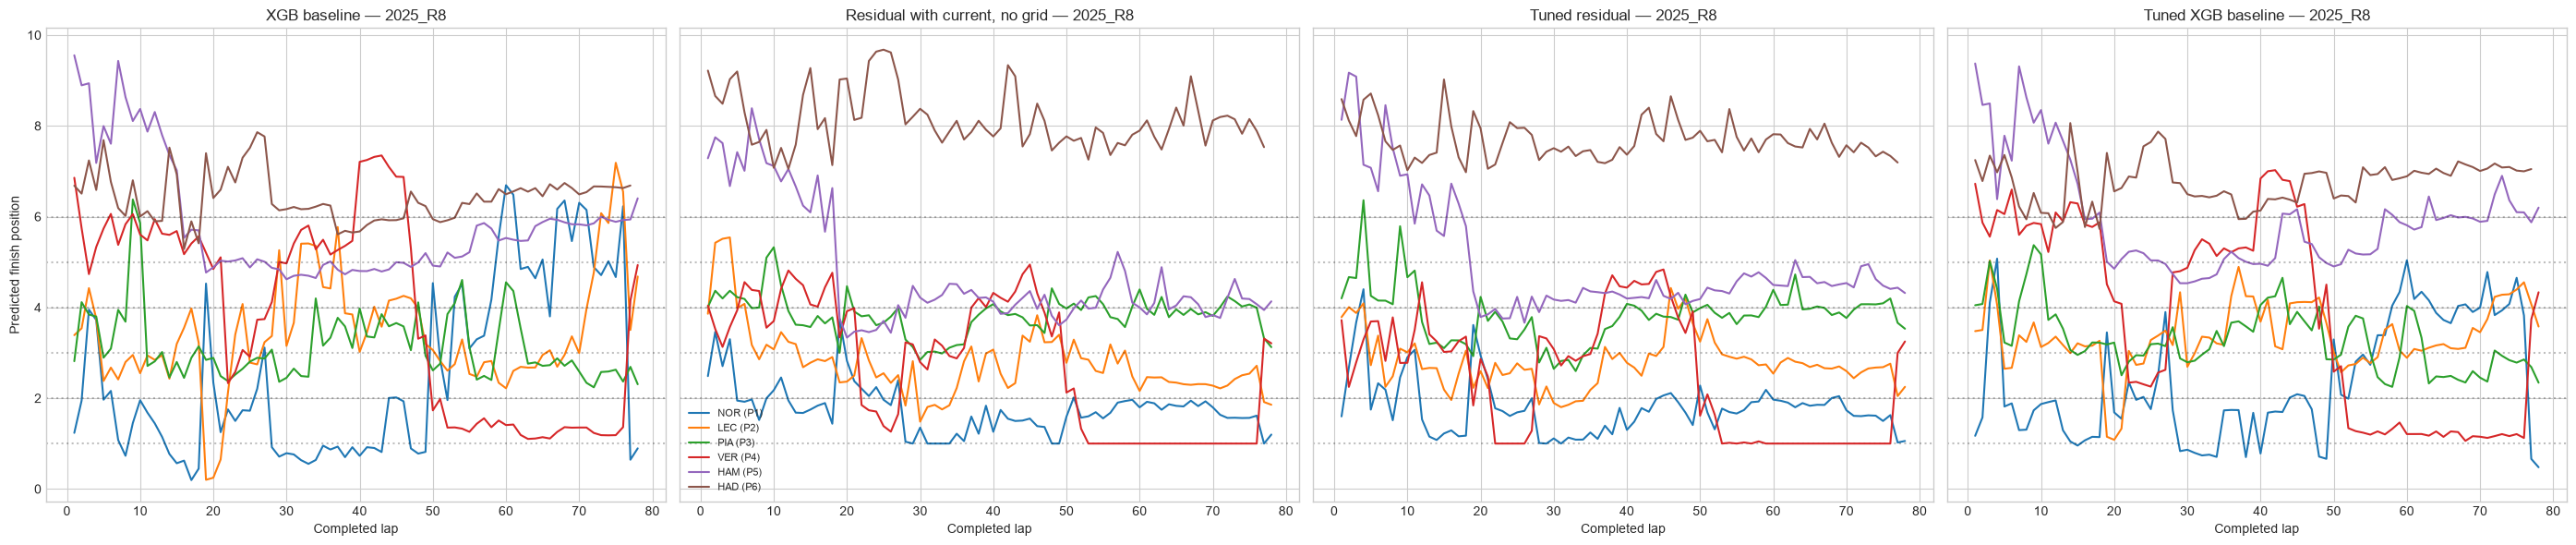

In [28]:
# Example race prediction paths
example_race = lap_test['race_id'].value_counts().index[0]
example = lap_test[lap_test['race_id'] == example_race].copy()
example['_row_id'] = example.index
finish_by_driver = example.groupby('driver')['finish_position'].first().sort_values()
drivers = finish_by_driver.head(6).index.tolist()

fig, axes = plt.subplots(1, len(comparison_models), figsize=(7 * len(comparison_models), 6), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, comparison_models):
    pred = predictions[name]['test']
    for driver in drivers:
        rows = example[example['driver'] == driver].sort_values('lap_number')
        values = pred[rows['_row_id'].to_numpy()]
        actual = rows['finish_position'].iloc[0]
        ax.plot(rows['lap_number'], values, label=f'{driver} (P{int(actual)})')
        ax.axhline(actual, linestyle=':', alpha=0.25, color='black')
    ax.set_title(f'{name} — {example_race}')
    ax.set_xlabel('Completed lap')
    ax.invert_yaxis()
axes[0].set_ylabel('Predicted finish position')
axes[1].legend(fontsize=8, loc='best')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_race_trajectories.png', dpi=150)
plt.show()

## 6. 2026 holdout

Use 2019–2024 for training, 2025 for validation, and 2026 for test. Do not tune model settings on 2026.

In [29]:
protocol_2026 = prepare_protocol(list(range(2019, 2025)), 2025, 2026)
train_2026 = add_position_delta_target(protocol_2026['lap_train'])
features_2026 = [
    c for c in IN_RACE_STATE_FEATURES
    if c not in {'pre_race_pred', 'position_delta_from_grid'}
]
model_2026_params = TUNED_PARAMS if TUNING_TARGET == 'residual' and TUNED_PARAMS else None
model_2026 = make_xgb(model_2026_params) if model_2026_params else make_xgb()
model_2026.fit(train_2026[features_2026], train_2026['finish_delta'])

normal_models_2026 = {
    'XGB baseline': (make_xgb(), IN_RACE_FEATURES),
    'XGB ablation': (make_xgb(), IN_RACE_FEATURES_ABLATION),
}
if BASELINE_TUNED_PARAMS:
    normal_models_2026['Tuned XGB baseline'] = (
        make_xgb(BASELINE_TUNED_PARAMS), IN_RACE_FEATURES
    )
    normal_models_2026['Tuned XGB ablation'] = (
        make_xgb(BASELINE_TUNED_PARAMS), IN_RACE_FEATURES_ABLATION
    )
for normal_model, normal_features in normal_models_2026.values():
    normal_model.fit(
        protocol_2026['lap_train'][normal_features],
        protocol_2026['lap_train']['finish_position'],
    )

holdout_rows = []
for split_name, frame in [
    ('validation 2025', protocol_2026['lap_val']),
    ('test 2026', protocol_2026['lap_test']),
]:
    for model_name, (normal_model, normal_features) in normal_models_2026.items():
        prediction = normal_model.predict(frame[normal_features])
        holdout_rows.append({
            'model': model_name,
            'split': split_name,
            **race_weighted_metrics(frame, prediction),
        })
    delta = model_2026.predict(frame[features_2026])
    pred = reconstruct_finish_from_delta(
        frame['current_position'], delta, max_position=22
    )
    holdout_rows.append({
        'model': 'Residual with current, no grid',
        'split': split_name,
        **race_weighted_metrics(frame, pred),
    })

display(pd.DataFrame(holdout_rows).round(4))

,model,split,mae,rmse,top1_exact,top3_hit,top10_hit
0,XGB baseline,validation 2025,2.2017,3.0493,0.1935,0.8207,0.9802
1,Tuned XGB baseline,validation 2025,2.1720,3.0120,0.1919,0.8267,0.9801
2,"Residual with current, no grid",validation 2025,2.3033,3.1700,0.1844,0.8002,0.9804
3,XGB baseline,test 2026,2.1394,3.1630,0.2159,0.8407,0.9769
4,Tuned XGB baseline,test 2026,2.1107,3.1242,0.2107,0.8476,0.9773
5,"Residual with current, no grid",test 2026,2.1780,3.2600,0.2183,0.8298,0.9750


## 7. Inspect one 2026 race

Set `RACE_TO_PLOT` to choose the 2026 race. The in-race models need one completed lap. This cell compares their first available race-state prediction. The pre-race view uses the grid and the existing RF pre-race model.

The tuned parameters were selected before the 2026 test race. The normal XGB line uses the separate normal-target tuning cell.

,driver,grid_position,pre_race_pred,Naive current position,XGB normal,XGB ablation,XGB tuned,XGB tuned ablation,Residual fixed,Residual fixed (no current),Residual tuned,Residual tuned (no current),finish_position
2,ANT,1.0,3.62,1.0,1.130000,1.920000,1.910000,2.07,4.72,3.67,3.88,2.99,1.0
9,HAM,3.0,4.67,2.0,4.130000,5.530000,4.310000,4.75,2.63,2.64,1.55,1.88,2.0
12,LEC,4.0,5.90,3.0,3.540000,3.680000,3.850000,4.08,3.48,4.25,3.29,3.43,17.0
8,HAD,5.0,8.75,4.0,6.850000,6.370000,6.120000,5.65,6.03,4.87,5.14,4.40,4.0
18,RUS,6.0,6.75,5.0,5.300000,5.880000,5.340000,5.52,5.12,5.61,5.01,5.56,12.0
17,PIA,7.0,8.18,6.0,8.340000,8.620000,7.890000,8.37,6.71,7.44,6.90,7.08,5.0
14,NOR,8.0,8.36,8.0,7.420000,9.030000,7.750000,9.17,6.70,6.49,7.14,6.49,19.0
7,GAS,9.0,9.31,7.0,10.300000,9.730000,9.680000,9.62,10.02,8.92,10.01,9.14,3.0
11,LAW,10.0,11.59,9.0,10.110000,10.070000,9.760000,9.96,9.75,9.92,9.89,10.13,6.0
0,ALB,11.0,13.46,10.0,11.770000,10.290000,11.510000,10.15,11.50,11.43,10.63,11.62,8.0


,model,mae,rmse,top1_exact,top3_hit,top10_hit
0,Naive current position,4.000,5.657,0.190,0.571,0.905
1,XGB normal,4.197,5.417,0.143,0.524,0.905
2,XGB ablation,4.313,5.255,0.048,0.429,0.952
3,XGB tuned,4.251,5.327,0.000,0.476,0.905
4,XGB tuned ablation,4.362,5.276,0.048,0.524,0.952
5,Residual fixed,4.471,5.632,0.000,0.429,0.905
6,Residual fixed (no current),4.358,5.513,0.048,0.476,0.905
7,Residual tuned,4.323,5.606,0.143,0.476,0.905
8,Residual tuned (no current),4.355,5.574,0.095,0.476,0.905


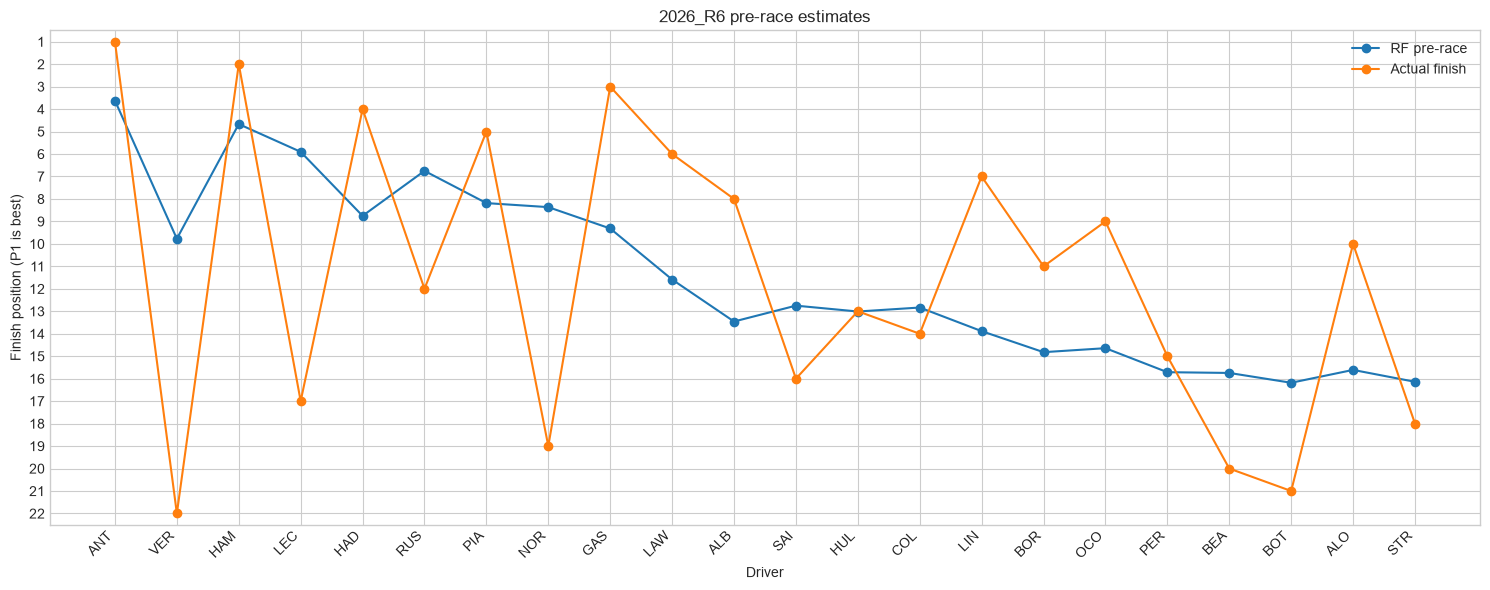

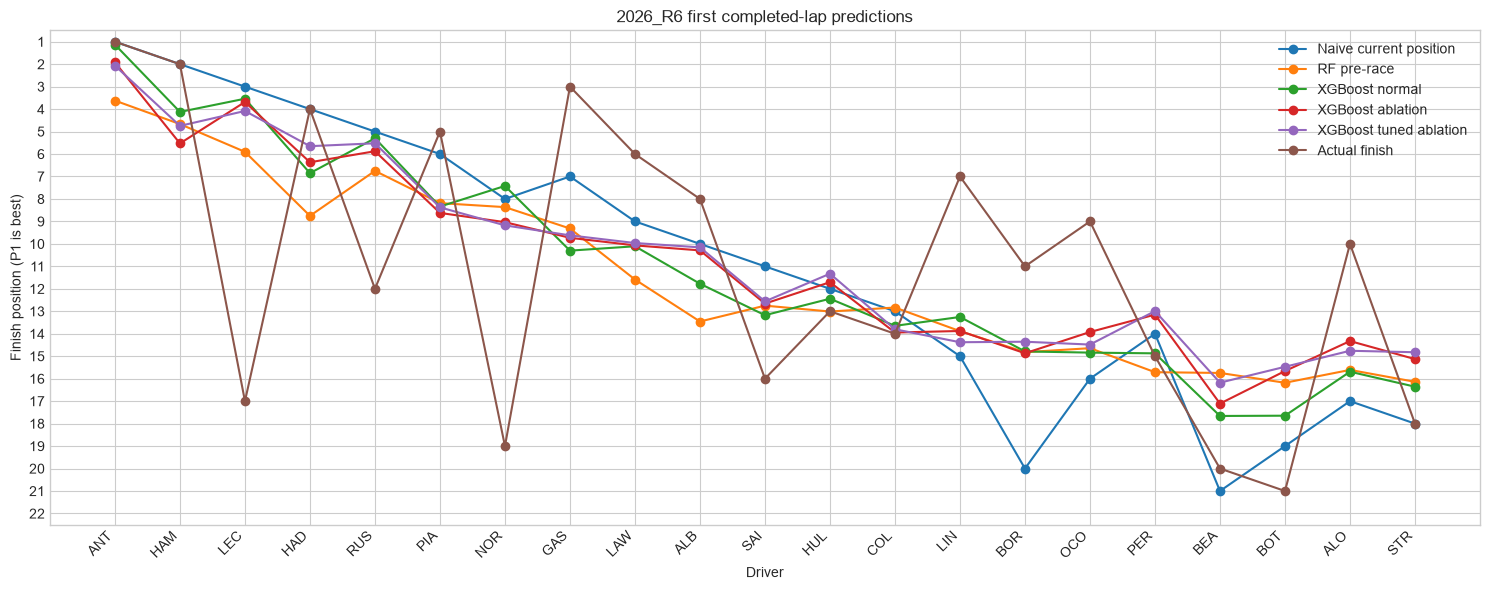

In [89]:
RACE_TO_PLOT = '2026_R6'
available_races_2026 = sorted(protocol_2026['pre_test']['race_id'].unique())
if RACE_TO_PLOT not in available_races_2026:
    raise ValueError(
        f'Unknown race: {RACE_TO_PLOT}. Choose one of: {available_races_2026}'
    )
race_slug = RACE_TO_PLOT.lower()
pre_first = protocol_2026['pre_test'].query("race_id == @RACE_TO_PLOT").copy()
laps_first = protocol_2026['lap_test'].query("race_id == @RACE_TO_PLOT").copy()
first_lap = (
    laps_first.sort_values(['driver', 'lap_number'])
    .groupby('driver', as_index=False)
    .head(1)
    .copy()
)

normal_model_2026 = make_xgb()
normal_model_2026.fit(
    protocol_2026['lap_train'][IN_RACE_FEATURES],
    protocol_2026['lap_train']['finish_position'],
)
normal_model_2026_ablation = make_xgb()
normal_model_2026_ablation.fit(
    protocol_2026['lap_train'][IN_RACE_FEATURES_ABLATION],
    protocol_2026['lap_train']['finish_position'],
)

residual_features_2026 = [
    c for c in IN_RACE_STATE_FEATURES
    if c not in {'pre_race_pred', 'position_delta_from_grid'}
]
residual_no_current_features_2026 = [
    c for c in IN_RACE_STATE_FEATURES
    if c not in {'current_position', 'pre_race_pred', 'position_delta_from_grid'}
]
residual_train_2026 = add_position_delta_target(protocol_2026['lap_train'])
residual_fixed_model_2026 = make_xgb()
residual_fixed_model_2026.fit(
    residual_train_2026[residual_features_2026],
    residual_train_2026['finish_delta'],
)

first_race_plot = first_lap[
    ['driver', 'grid_position', 'current_position', 'finish_position']
].copy()
first_race_plot['Naive current position'] = first_race_plot['current_position']
first_race_plot['XGB normal'] = normal_model_2026.predict(
    first_lap[IN_RACE_FEATURES]
)
first_race_plot['XGB ablation'] = normal_model_2026_ablation.predict(
    first_lap[IN_RACE_FEATURES_ABLATION]
)

fixed_delta = residual_fixed_model_2026.predict(first_lap[residual_features_2026])
first_race_plot['Residual fixed'] = reconstruct_finish_from_delta(
    first_lap['current_position'], fixed_delta, max_position=22
)
residual_no_current_fixed_model_2026 = make_xgb()
residual_no_current_fixed_model_2026.fit(
    residual_train_2026[residual_no_current_features_2026],
    residual_train_2026['finish_delta'],
)
no_current_fixed_delta = residual_no_current_fixed_model_2026.predict(
    first_lap[residual_no_current_features_2026]
)
first_race_plot['Residual fixed (no current)'] = reconstruct_finish_from_delta(
    first_lap['current_position'], no_current_fixed_delta, max_position=22
)

model_columns = [
    'Naive current position',
    'XGB normal',
    'XGB ablation',
]
if BASELINE_TUNED_PARAMS:
    tuned_normal_model_2026 = make_xgb(BASELINE_TUNED_PARAMS)
    tuned_normal_model_2026.fit(
        protocol_2026['lap_train'][IN_RACE_FEATURES],
        protocol_2026['lap_train']['finish_position'],
    )
    first_race_plot['XGB tuned'] = tuned_normal_model_2026.predict(
        first_lap[IN_RACE_FEATURES]
    )
    tuned_normal_model_2026_ablation = make_xgb(BASELINE_TUNED_PARAMS)
    tuned_normal_model_2026_ablation.fit(
        protocol_2026['lap_train'][IN_RACE_FEATURES_ABLATION],
        protocol_2026['lap_train']['finish_position'],
    )
    first_race_plot['XGB tuned ablation'] = tuned_normal_model_2026_ablation.predict(
        first_lap[IN_RACE_FEATURES_ABLATION]
    )
    model_columns.extend(['XGB tuned', 'XGB tuned ablation'])

model_columns.extend([
    'Residual fixed',
    'Residual fixed (no current)',
])
if TUNED_PARAMS:

    tuned_delta_model_2026 = make_xgb(TUNED_PARAMS)
    tuned_delta_model_2026.fit(
        residual_train_2026[residual_features_2026],
        residual_train_2026['finish_delta'],
    )
    tuned_delta = tuned_delta_model_2026.predict(first_lap[residual_features_2026])
    first_race_plot['Residual tuned'] = reconstruct_finish_from_delta(
        first_lap['current_position'], tuned_delta, max_position=22
    )
    tuned_no_current_delta_model_2026 = make_xgb(TUNED_PARAMS)
    tuned_no_current_delta_model_2026.fit(
        residual_train_2026[residual_no_current_features_2026],
        residual_train_2026['finish_delta'],
    )
    tuned_no_current_delta = tuned_no_current_delta_model_2026.predict(
        first_lap[residual_no_current_features_2026]
    )
    first_race_plot['Residual tuned (no current)'] = reconstruct_finish_from_delta(
        first_lap['current_position'], tuned_no_current_delta, max_position=22
    )
    model_columns.extend([
        'Residual tuned', 'Residual tuned (no current)',
    ])
if not BASELINE_TUNED_PARAMS and not TUNED_PARAMS:
    print('No tuned parameters found. Run the Bayesian tuning cells first.')

first_race_plot = first_race_plot.merge(
    pre_first[['driver', 'pre_race_pred']], on='driver', how='left'
).sort_values(['grid_position', 'driver'])
first_race_plot['RF pre-race'] = first_race_plot['pre_race_pred']
first_race_table = first_race_plot[
    ['driver', 'grid_position', 'pre_race_pred'] + model_columns + ['finish_position']
].round(4)
first_race_table.to_csv(FIGURES_DIR / f'{race_slug}_first_lap_predictions.csv', index=False)
display(first_race_table.round(2))

first_race_metrics = []
for name in model_columns:
    first_race_metrics.append({
        'model': name,
        **regression_metrics(first_race_plot['finish_position'], first_race_plot[name]),
    })
first_race_metrics = pd.DataFrame(first_race_metrics).round(4)
first_race_metrics.to_csv(FIGURES_DIR / f'{race_slug}_first_lap_metrics.csv', index=False)
display(first_race_metrics.round(3))

pre_race_plot = pre_first[
    ['driver', 'grid_position', 'pre_race_pred', 'finish_position']
].sort_values(['grid_position', 'driver']).set_index('driver')
ax = pre_race_plot[
    ['pre_race_pred', 'finish_position']
].rename(columns={
    'pre_race_pred': 'RF pre-race',
    'finish_position': 'Actual finish',
}).plot(marker='o', figsize=(15, 6))
ax.set_xticks(range(len(pre_race_plot.index)))
ax.set_xticklabels(pre_race_plot.index, rotation=45, ha='right')
ax.set_yticks(range(1, 23))
ax.set_ylim(22.5, 0.5)
ax.set_xlabel('Driver')
ax.set_ylabel('Finish position (P1 is best)')
ax.set_title(f'{RACE_TO_PLOT} pre-race estimates')
ax.figure.tight_layout()
ax.figure.savefig(FIGURES_DIR / f'{race_slug}_pre_race_comparison.png', dpi=150)
plt.show()

final_plot_columns = [
    'Naive current position',
    'RF pre-race',
    'XGB normal',
    'XGB ablation',
    'XGB tuned ablation',
]
final_plot_columns = [c for c in final_plot_columns if c in first_race_plot.columns]
first_lap_plot = first_race_plot.set_index('driver')[
    final_plot_columns + ['finish_position']
].rename(columns={
    'XGB normal': 'XGBoost normal',
    'XGB ablation': 'XGBoost ablation',
    'XGB tuned ablation': 'XGBoost tuned ablation',
    'finish_position': 'Actual finish',
})
ax = first_lap_plot.plot(marker='o', figsize=(15, 6))
ax.set_xticks(range(len(first_race_plot.index)))
ax.set_xticklabels(first_race_plot['driver'], rotation=45, ha='right')
ax.set_yticks(range(1, 23))
ax.set_ylim(22.5, 0.5)
ax.set_xlabel('Driver')
ax.set_ylabel('Finish position (P1 is best)')
ax.set_title(f'{RACE_TO_PLOT} first completed-lap predictions')
ax.figure.tight_layout()
ax.figure.savefig(FIGURES_DIR / f'{race_slug}_first_lap_model_comparison.png', dpi=150)
plt.show()

## 7.1 Specific driver prediction by lap

Set `RACE_TO_PLOT` in the previous cell to choose the 2026 race. Set `DRIVER_TO_PLOT` below to choose the driver. Time 0 is the pre-race estimate. The in-race models start after lap 1 because they need completed-lap data.

,lap_number,Actual finish,Naive current position,RF pre-race,XGB normal,XGB ablation,XGB tuned,XGB tuned ablation,Residual fixed,Residual fixed (no current),Residual tuned,Residual tuned (no current)
0,0,3.0,9.0,9.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,3.0,7.0,NaN,10.30,9.73,9.68,9.62,10.02,8.92,10.01,9.14
2,2,3.0,7.0,NaN,10.60,10.74,9.86,10.19,10.01,8.68,9.90,8.32
3,3,3.0,7.0,NaN,10.48,10.49,9.69,10.19,9.71,8.21,9.92,7.83
4,4,3.0,7.0,NaN,9.53,9.21,8.92,8.91,8.61,7.52,8.40,7.02
...,...,...,...,...,...,...,...,...,...,...,...,...
74,74,3.0,3.0,NaN,3.64,2.90,3.57,2.98,3.30,3.12,2.93,2.58
75,75,3.0,3.0,NaN,3.83,2.72,3.48,2.96,3.32,3.11,2.98,2.62
76,76,3.0,3.0,NaN,3.83,2.82,3.54,2.93,3.26,3.00,2.86,2.52
77,77,3.0,3.0,NaN,3.85,2.88,3.55,3.04,2.98,2.76,2.94,2.39


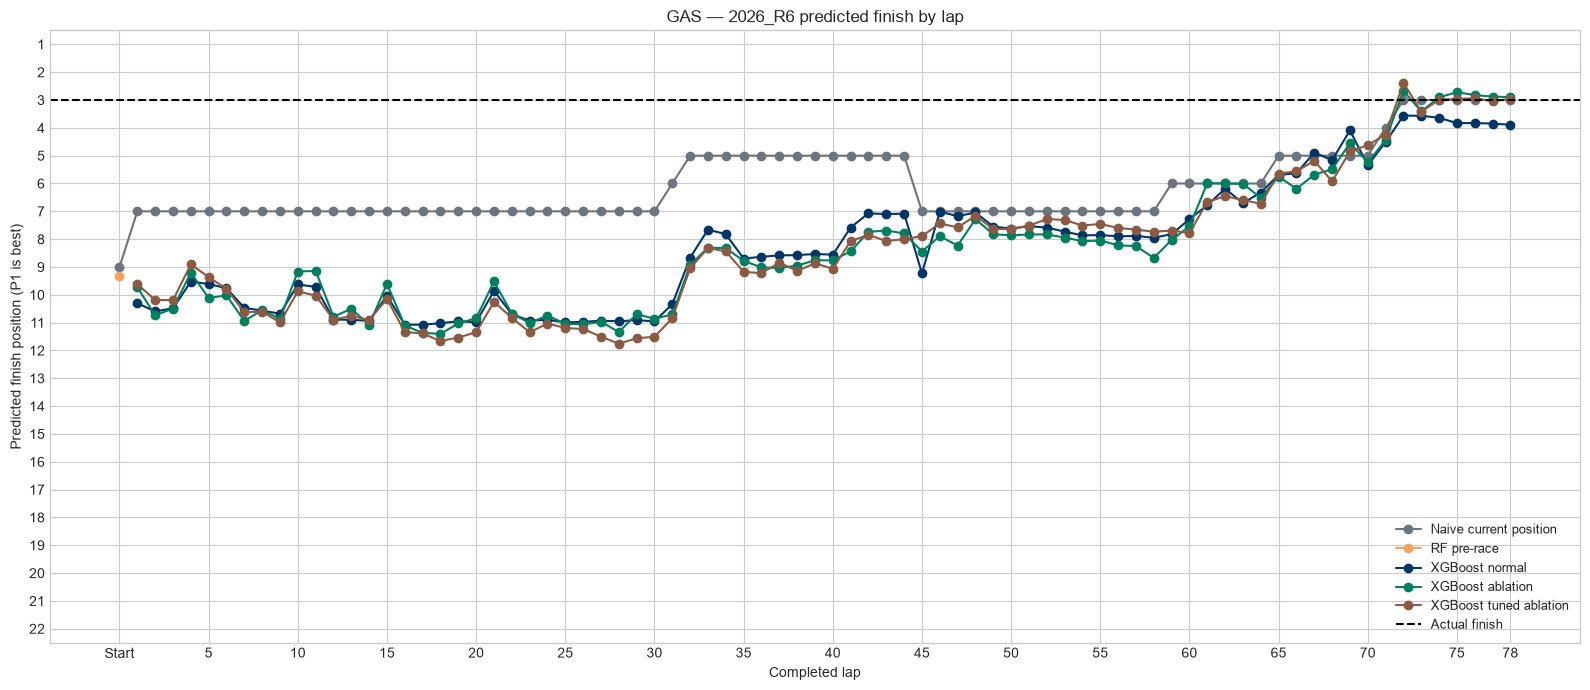

In [98]:
DRIVER_TO_PLOT = 'GAS'
driver_pre = pre_first[pre_first['driver'] == DRIVER_TO_PLOT].iloc[0]
driver_laps = laps_first[laps_first['driver'] == DRIVER_TO_PLOT].sort_values('lap_number').copy()

driver_trajectory = pd.DataFrame({
    'lap_number': [0] + driver_laps['lap_number'].tolist(),
    'Actual finish': [driver_pre['finish_position']] * (len(driver_laps) + 1),
    'Naive current position': [driver_pre['grid_position']] + driver_laps['current_position'].tolist(),
    'RF pre-race': [driver_pre['pre_race_pred']] + [np.nan] * len(driver_laps),
})

driver_trajectory['XGB normal'] = [np.nan] + normal_model_2026.predict(
    driver_laps[IN_RACE_FEATURES]
).tolist()
driver_trajectory['XGB ablation'] = [np.nan] + normal_model_2026_ablation.predict(
    driver_laps[IN_RACE_FEATURES_ABLATION]
).tolist()
if BASELINE_TUNED_PARAMS:
    driver_trajectory['XGB tuned'] = [np.nan] + tuned_normal_model_2026.predict(
        driver_laps[IN_RACE_FEATURES]
    ).tolist()
    driver_trajectory['XGB tuned ablation'] = [np.nan] + tuned_normal_model_2026_ablation.predict(
        driver_laps[IN_RACE_FEATURES_ABLATION]
    ).tolist()

driver_residual_models = {
    'Residual fixed': (residual_fixed_model_2026, residual_features_2026),
    'Residual fixed (no current)': (
        residual_no_current_fixed_model_2026, residual_no_current_features_2026
    ),
}
if TUNED_PARAMS:
    driver_residual_models.update({
        'Residual tuned': (tuned_delta_model_2026, residual_features_2026),
        'Residual tuned (no current)': (
            tuned_no_current_delta_model_2026, residual_no_current_features_2026
        ),
    })

for name, (model, features) in driver_residual_models.items():
    delta = model.predict(driver_laps[features])
    finish_prediction = reconstruct_finish_from_delta(
        driver_laps['current_position'], delta, max_position=22
    )
    driver_trajectory[name] = [np.nan] + finish_prediction.tolist()

trajectory_path = FIGURES_DIR / f'{race_slug}_{DRIVER_TO_PLOT.lower()}_prediction_trajectory.csv'
driver_trajectory.to_csv(
    trajectory_path, index=False
)
display(driver_trajectory.round(2))

colors = {
    'Naive current position': '#6c757d',
    'RF pre-race': '#f4a261',
    'XGB normal': '#003566',
    'XGB ablation': '#007f5f',
    'XGB tuned ablation': '#8a5a44',
}
plot_columns = [c for c in colors if c in driver_trajectory.columns]
trajectory_plot = driver_trajectory[['lap_number'] + plot_columns].rename(columns={
    'XGB normal': 'XGBoost normal',
    'XGB ablation': 'XGBoost ablation',
    'XGB tuned ablation': 'XGBoost tuned ablation',
})
plot_colors = [colors[c] for c in plot_columns]
ax = trajectory_plot.plot(
    x='lap_number', y=[c for c in trajectory_plot.columns if c != 'lap_number'],
    marker='o', figsize=(16, 7), color=plot_colors,
)
ax.axhline(driver_pre['finish_position'], color='black', linestyle='--', linewidth=1.5, label='Actual finish')
tick_laps = [0] + list(range(5, int(driver_trajectory['lap_number'].max()) + 1, 5))
last_lap = int(driver_trajectory['lap_number'].max())
if last_lap not in tick_laps:
    tick_laps.append(last_lap)
ax.set_xticks(tick_laps)
ax.set_xticklabels(['Start' if lap == 0 else str(lap) for lap in tick_laps])
ax.set_yticks(range(1, 23))
ax.set_ylim(22.5, 0.5)
ax.set_xlabel('Completed lap')
ax.set_ylabel('Predicted finish position (P1 is best)')
ax.set_title(f'{DRIVER_TO_PLOT} — {RACE_TO_PLOT} predicted finish by lap')
ax.legend(loc='lower right', fontsize=9)
ax.figure.tight_layout()
ax.figure.savefig(FIGURES_DIR / f'{race_slug}_{DRIVER_TO_PLOT.lower()}_prediction_trajectory.png', dpi=150)
plt.show()

## 8. Interpretation

Use the tables to select the model. The main selection rule is 2025 test error by checkpoint.

A model is useful if it beats the current-position baseline at several checkpoints and does not fail on the 2026 holdout.